# Task 3 — Final CycleGAN Artifact Evidence

Training was performed using `train.py`; this notebook reproduces artifact loading, evaluation evidence, and final outputs without retraining.

In [1]:
from pathlib import Path
import sys, json, csv
import torch
from IPython.display import display, Image

ROOT = Path.cwd()
SRC = ROOT / "src"
sys.path.insert(0, str(SRC.resolve()))

from models import Generator, MultiScaleDiscriminator, count_parameters

print("Imported Generator, MultiScaleDiscriminator, and count_parameters.")


Imported Generator, MultiScaleDiscriminator, and count_parameters.


In [2]:
config_path = SRC / "config_final.json"
config = json.loads(config_path.read_text())

print("Final configuration:")
print(json.dumps(config, indent=2))


Final configuration:
{
  "seed": 8511,
  "image_size": 256,
  "resize_size": 286,
  "channels": 3,
  "base_channels": 64,
  "generator_res_blocks": 9,
  "use_spectral_norm": false,
  "batch_size": 2,
  "epochs": 300,
  "updates_per_epoch": 150,
  "constant_lr_epochs": 150,
  "learning_rate": 0.0002,
  "beta1": 0.5,
  "beta2": 0.999,
  "lambda_cycle": 10.0,
  "lambda_identity": 5.0,
  "replay_buffer_size": 50,
  "num_workers": 2,
  "save_every_epochs": 100,
  "sample_every_epochs": 100,
  "data_root": "./data",
  "output_root": "./outputs"
}


In [3]:
checkpoint_path = ROOT / "outputs_final_multiscale" / "checkpoints" / "epoch_0300.pt"

# Memory-efficient loading of the existing checkpoint only.
checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=True,
    mmap=True
)

print("Checkpoint loaded successfully.")
print("Path:", checkpoint_path)
print("Checkpoint keys:", list(checkpoint.keys()))
print("Recorded epoch:", checkpoint.get("epoch"))
del checkpoint


Checkpoint loaded successfully.
Path: /workspace/DATA266-Lab1-Pair25/task3_gan/praveen/outputs_final_multiscale/checkpoints/epoch_0300.pt
Checkpoint keys: ['epoch', 'models', 'optimizers', 'schedulers', 'history']
Recorded epoch: 300


In [4]:
def read_csv(path):
    with open(path, newline="", encoding="utf-8-sig") as f:
        return list(csv.DictReader(f))

metrics_path = ROOT / "full_metrics_report.csv"
metrics_rows = read_csv(metrics_path)

print("full_metrics_report.csv")
for row in metrics_rows:
    print(row)


full_metrics_report.csv
{'direction': 'A2B', 'metric': 'FID', 'value': '98.329445', 'status': 'local_validation', 'notes': 'Computed by local evaluator; replace with official value if required'}
{'direction': 'B2A', 'metric': 'FID', 'value': '92.867265', 'status': 'local_validation', 'notes': 'Computed by local evaluator; replace with official value if required'}
{'direction': 'A2B', 'metric': 'KID', 'value': '', 'status': 'pending', 'notes': 'Not computed from current observed outputs; use class-approved evaluator or human audit'}
{'direction': 'B2A', 'metric': 'KID', 'value': '', 'status': 'pending', 'notes': 'Not computed from current observed outputs; use class-approved evaluator or human audit'}
{'direction': 'A2B', 'metric': 'generative_precision', 'value': '', 'status': 'pending', 'notes': 'Not computed from current observed outputs; use class-approved evaluator or human audit'}
{'direction': 'B2A', 'metric': 'generative_precision', 'value': '', 'status': 'pending', 'notes': 'No

In [5]:
wanted = {
    "fid", "mifid", "kid", "precision", "recall",
    "lpips", "cycle_l1", "content_cosine"
}

print("Final reported metric values:")
for row in metrics_rows:
    metric = str(row.get("metric", "")).strip().lower()
    if metric in wanted:
        print(
            row.get("direction"),
            metric,
            "=",
            row.get("value"),
            "| status:",
            row.get("status"),
            "| notes:",
            row.get("notes")
        )


Final reported metric values:
A2B fid = 98.329445 | status: local_validation | notes: Computed by local evaluator; replace with official value if required
B2A fid = 92.867265 | status: local_validation | notes: Computed by local evaluator; replace with official value if required
A2B kid =  | status: pending | notes: Not computed from current observed outputs; use class-approved evaluator or human audit
B2A kid =  | status: pending | notes: Not computed from current observed outputs; use class-approved evaluator or human audit
A2B lpips =  | status: pending | notes: Not computed from current observed outputs; use class-approved evaluator or human audit
B2A lpips =  | status: pending | notes: Not computed from current observed outputs; use class-approved evaluator or human audit
A2B cycle_l1 =  | status: pending | notes: Not computed from current observed outputs; use class-approved evaluator or human audit
B2A cycle_l1 =  | status: pending | notes: Not computed from current observed out

In [6]:
audit_path = ROOT / "outputs" / "human_audit_summary.csv"

if audit_path.exists():
    audit_rows = read_csv(audit_path)
    print("human_audit_summary.csv")
    for row in audit_rows:
        print(row)
else:
    print("Human-audit summary not found:", audit_path)


Human-audit summary not found: /workspace/DATA266-Lab1-Pair25/task3_gan/praveen/outputs/human_audit_summary.csv


A2B displayed files: 3
000c1e3bff.jpg


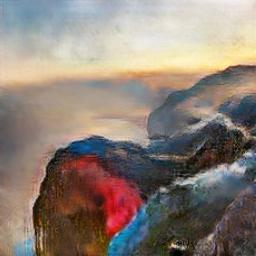

011835cfbf.jpg


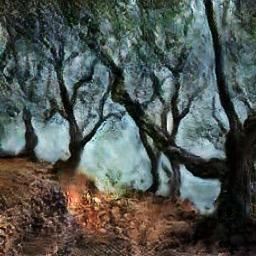

0260d15306.jpg


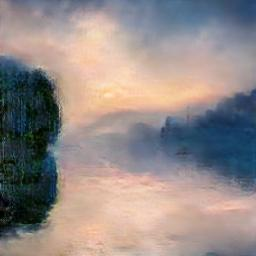

B2A displayed files: 3
00068bc07f.jpg


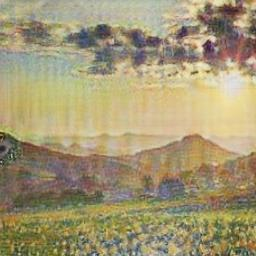

000910d219.jpg


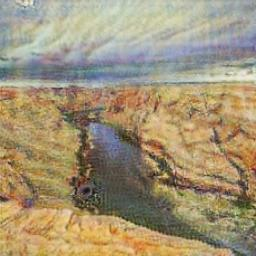

000ded5c41.jpg


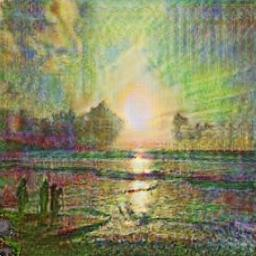

In [7]:
for direction in ["A2B", "B2A"]:
    folder = ROOT / "outputs_final_multiscale" / f"inference_{direction}"
    files = sorted([
        p for p in folder.glob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])[:3]

    print(f"{direction} displayed files:", len(files))
    for path in files:
        print(path.name)
        display(Image(filename=str(path), width=350))
